<a href="https://colab.research.google.com/github/cafauzi13/ESG_SentimentAnalysis/blob/main/scripts/EDA_FeatExt_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inisiasi

In [1]:
!pip install deep-translator textblob
!pip install -q pandas matplotlib seaborn scikit-learn transformers torch openpyxl
!pip install spacy


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
from google.colab import files
from textblob import TextBlob
from deep_translator import GoogleTranslator
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from transformers import pipeline


In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [3]:
# Upload dan Load Data
#github_url = ''

# try:
    #"df = pd.read_csv(github_url)
    #if 'Isi Berita Clean' in df.columns and 'clean_text' not in df.columns:
        #df.rename(columns={'Isi Berita Clean': 'clean_text'}, inplace=True)

    #print(f'✅ Dataset berhasil di-load! Total data: {df.shape[0]} baris.')
#except Exception as e:
    #print(f'❌ Gagal load data!. Error: {e}')

print("📂 Pilih file CSV hasil cleaning (misal: clean_data.csv)")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

📂 Pilih file CSV hasil cleaning (misal: clean_data.csv)


Saving clean_data.csv to clean_data (2).csv


# EDA

In [4]:
# Cek Kualitas Data Dasar
print("\n=== RINGKASAN DATA ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df[['Isi Berita Clean', 'Sentiment', 'Tag']].isnull().sum())
df = df.dropna(subset=['Isi Berita Clean']).reset_index(drop=True)

# Tambahkan metrik panjang kata
df['panjang_kata'] = df['Isi Berita Clean'].apply(lambda x: len(str(x).split()))

print("\n--- Ringkasan Data ---")
print(df.info())
display(df.head())


=== RINGKASAN DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   No                353 non-null    int64 
 1   Link              353 non-null    object
 2   Sentiment         353 non-null    object
 3   Penerbit          304 non-null    object
 4   Tag               352 non-null    object
 5   Perusahaan        174 non-null    object
 6   Tahun             143 non-null    object
 7   Isi Berita Clean  353 non-null    object
 8   teks_bersih       353 non-null    object
 9   tokens            353 non-null    object
 10  jumlah_token      353 non-null    int64 
dtypes: int64(2), object(9)
memory usage: 30.5+ KB
None

=== MISSING VALUES ===
Isi Berita Clean    0
Sentiment           0
Tag                 1
dtype: int64

--- Ringkasan Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (tota

,No,Link,Sentiment,Penerbit,Tag,Perusahaan,Tahun,Isi Berita Clean,teks_bersih,tokens,jumlah_token,panjang_kata
0,1,https://finansial.bisnis.com/read/20230908/90/...,Positif,Bisnis.com,Finance,Bank BRI,2023,"Bisnis.com, JAKARTA - Sukses dalam transisi en...",bisnis com jakarta sukses dalam transisi energ...,"[""bisnis"", ""com"", ""jakarta"", ""sukses"", ""transi...",237,363
1,3,https://finansial.bisnis.com/read/20231108/90/...,Positif,Bisnis.com,Governance,Bank Mandiri,2023,"Bisnis.com, JAKARTA - Bank Mandiri berhasil me...",bisnis com jakarta bank mandiri berhasil mence...,"[""bisnis"", ""com"", ""jakarta"", ""bank"", ""mandiri""...",370,560
2,4,https://finansial.bisnis.com/read/20250206/90/...,Positif,Bisnis.com,Finance,Bank Mandiri,2023,"Bisnis.com, JAKARTA - Bank Mandiri terus mempe...",bisnis com jakarta bank mandiri terus memperku...,"[""bisnis"", ""com"", ""jakarta"", ""bank"", ""mandiri""...",808,1261
3,5,https://finansial.bisnis.com/read/20250209/90/...,Positif,Bisnis.com,Environment,Bank Mandiri,2025,"Bisnis.com, JAKARTA - Bank Mandiri kembali men...",bisnis com jakarta bank mandiri kembali menunj...,"[""bisnis"", ""com"", ""jakarta"", ""bank"", ""mandiri""...",443,645
4,8,https://keuangan.kontan.co.id/news/green-finan...,Positif,Kontan,Finance,Bank BSI,2025,Reporter Selvi Mayasari Editor Ignatia Maria S...,reporter selvi mayasari editor ignatia maria s...,"[""reporter"", ""selvi"", ""mayasari"", ""editor"", ""i...",262,418


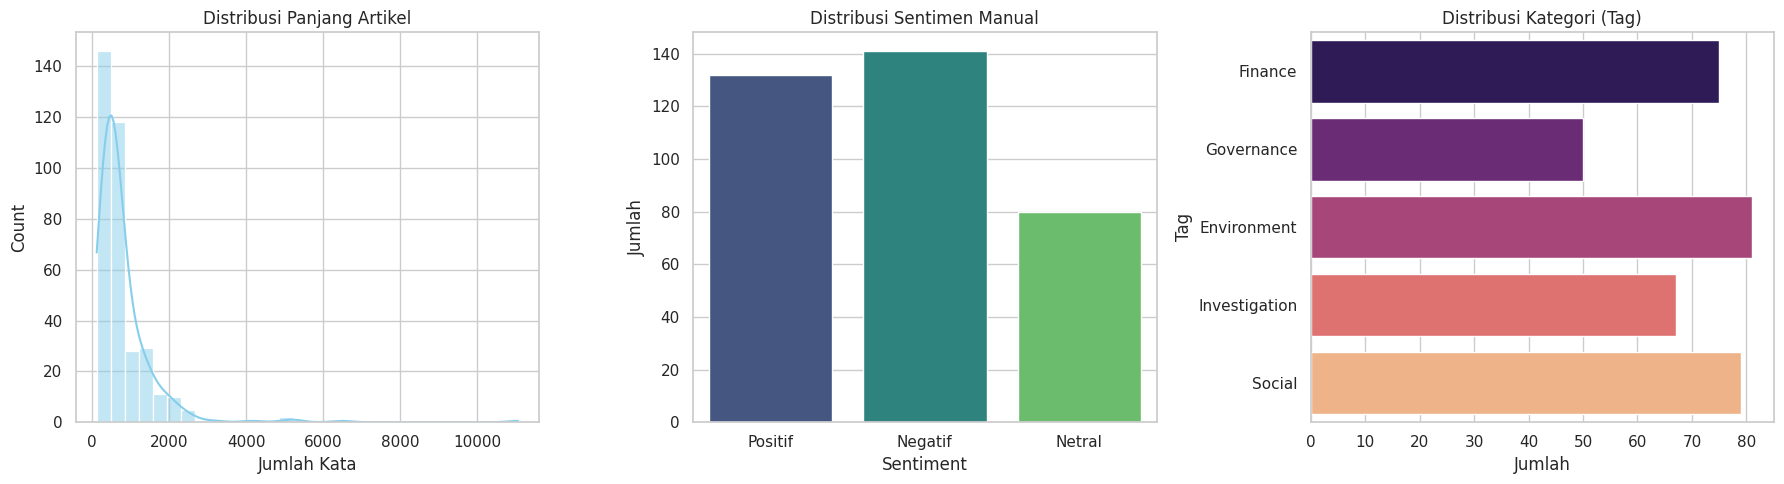

In [5]:
# 3. Visualisasi EDA Dasar
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Distribusi Panjang Kata
sns.histplot(df['panjang_kata'], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Panjang Artikel')
axes[0].set_xlabel('Jumlah Kata')

# Plot B: Distribusi Sentimen
sns.countplot(data=df, x='Sentiment', palette='viridis', order=['Positif', 'Negatif', 'Netral'], ax=axes[1])
axes[1].set_title('Distribusi Sentimen Manual')
axes[1].set_ylabel('Jumlah')

# Plot C: Distribusi Kategori (Tag)
sns.countplot(data=df, y='Tag', palette='magma', ax=axes[2])
axes[2].set_title('Distribusi Kategori (Tag)')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()


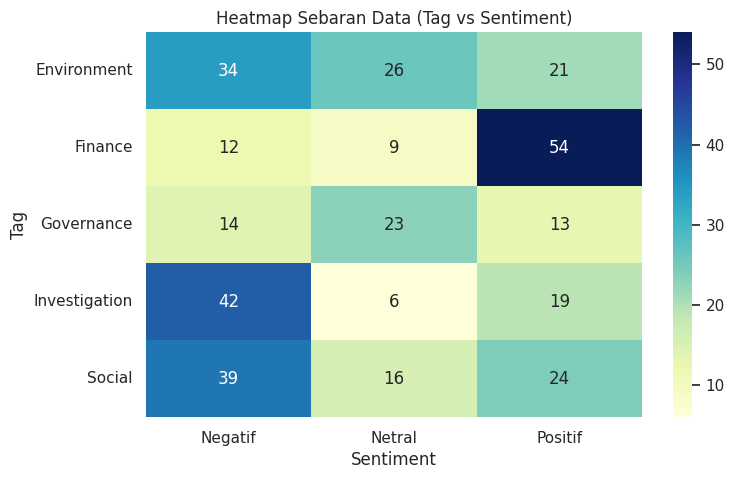

In [6]:
# 4. Tabel Silang (Cross-Tabulation) & Heatmap
cross_tab = pd.crosstab(df['Tag'], df['Sentiment'])
plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap Sebaran Data (Tag vs Sentiment)')
plt.show()

In [7]:
# 5. GATE KEPUTUSAN (PIPELINE B5)
def gate_keputusan_b5(dataframe, min_target=15):
    print("\n" + "="*40)
    print("🚦 GATE B5: STATUS KEBUTUHAN DATA")
    print("="*40)

    ct = pd.crosstab(dataframe['Tag'], dataframe['Sentiment'])
    kekurangan_data = []

    for tag in ct.index:
        for sent in ct.columns:
            jumlah = ct.loc[tag, sent]
            if jumlah < min_target:
                butuh = min_target - jumlah
                kekurangan_data.append({'Tag': tag, 'Sentimen': sent, 'Kurang': butuh})

    if not kekurangan_data:
        print("✅ STATUS: AMAN. Lanjut ke ekstraksi fitur (TF-IDF/POS Tagging).")
    else:
        print("⚠️ STATUS: BUTUH TAMBAHAN ARTIKEL!")
        print("Silakan infokan ke Pipeline A (Tim Scraping) untuk mencari:")
        df_kurang = pd.DataFrame(kekurangan_data)
        display(df_kurang)

# Panggil fungsi gate keputusan
gate_keputusan_b5(df, min_target=5)


🚦 GATE B5: STATUS KEBUTUHAN DATA
✅ STATUS: AMAN. Lanjut ke ekstraksi fitur (TF-IDF/POS Tagging).



### TEXTBLOB SENTIMENT (VIA TRANSLATION)


⏳ Memulai proses translasi ke Bahasa Inggris (Please wait yh)...
   Translasi baris ke-50 selesai...
   Translasi baris ke-100 selesai...
   Translasi baris ke-150 selesai...
   Translasi baris ke-200 selesai...
   Translasi baris ke-250 selesai...
   Translasi baris ke-300 selesai...
   Translasi baris ke-350 selesai...
✅ Translasi & Scoring selesai dalam 256.97 detik.


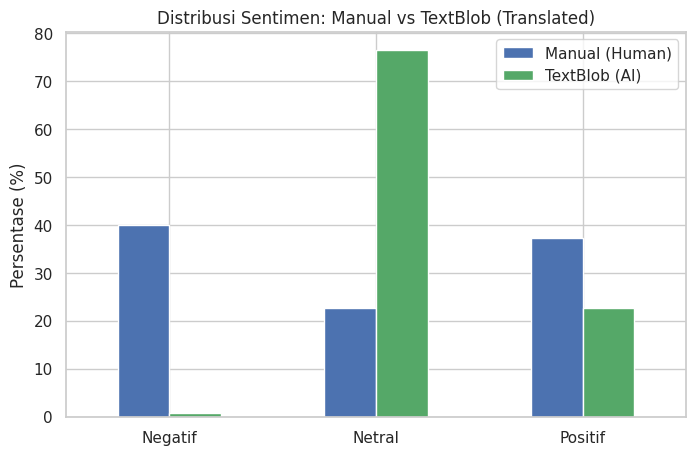


--- LAPORAN VALIDASI TEXTBLOB ---
Akurasi: 0.26
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       141
      Netral       0.19      0.64      0.29        80
     Positif       0.53      0.32      0.40       132

    accuracy                           0.26       353
   macro avg       0.24      0.32      0.23       353
weighted avg       0.24      0.26      0.21       353



In [8]:
print("⏳ Memulai proses translasi ke Bahasa Inggris (Please wait yh)...")

# 1. Fungsi Translasi (Aman dari limit API Colab)
def translate_to_english(text):
    try:
        # Batasi 6000 karakter agar tidak error kena limit Google Translate
        text_sliced = str(text)[:6000]
        translated = GoogleTranslator(source='id', target='en').translate(text_sliced)
        return translated
    except Exception as e:
        return "" # Return kosong jika gagal

# 2. Fungsi TextBlob Scoring
def get_textblob_label(text):
    if not text: return 'Netral'

    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return 'Positif'
    elif score < -0.1:
        return 'Negatif'
    else:
        return 'Netral'

# 3. Eksekusi Translasi & Scoring
# Gunakan progress_apply jika tqdm sudah diinstall (opsional), jika tidak pakai apply biasa
# Disini kita pakai .apply biasa tapi cetak progress per 50 baris
start_time = time.time()

english_texts = []
for i, text in enumerate(df['Isi Berita Clean']):
    if i % 50 == 0 and i > 0:
        print(f"   Translasi baris ke-{i} selesai...")
    english_texts.append(translate_to_english(text))

df['Teks_English'] = english_texts
df['Sentiment_TextBlob'] = df['Teks_English'].apply(get_textblob_label)

print(f"✅ Translasi & Scoring selesai dalam {(time.time() - start_time):.2f} detik.")

# 4. Evaluasi & Visualisasi TextBlob
dist_manual = df['Sentiment'].value_counts(normalize=True) * 100
dist_blob = df['Sentiment_TextBlob'].value_counts(normalize=True) * 100

df_dist = pd.DataFrame({'Manual (Human)': dist_manual, 'TextBlob (AI)': dist_blob}).fillna(0)

plt.figure(figsize=(8, 5))
df_dist.plot(kind='bar', color=['#4C72B0', '#55A868'], ax=plt.gca())
plt.title('Distribusi Sentimen: Manual vs TextBlob (Translated)')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.show()

# 5. Laporan Performa TextBlob
print("\n--- LAPORAN VALIDASI TEXTBLOB ---")

# Filter out NaN values from 'Sentiment' column before evaluation
df_filtered = df.dropna(subset=['Sentiment']).copy()

print(f"Akurasi: {accuracy_score(df_filtered['Sentiment'], df_filtered['Sentiment_TextBlob']):.2f}")
print(classification_report(df_filtered['Sentiment'], df_filtered['Sentiment_TextBlob']))

### INSET LEXICON DENGAN NEGATION HANDLING

In [9]:
print("📂 Memuat InSet Lexicon dari GitHub...")
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

try:
    df_pos = pd.read_csv(url_pos, sep='\t', names=['word', 'weight'])
    df_neg = pd.read_csv(url_neg, sep='\t', names=['word', 'weight'])
    df_pos['weight'] = pd.to_numeric(df_pos['weight'], errors='coerce').fillna(0).astype(int)
    df_neg['weight'] = pd.to_numeric(df_neg['weight'], errors='coerce').fillna(0).astype(int)

    inset_dict = dict(zip(df_pos['word'], df_pos['weight']))
    inset_dict.update(dict(zip(df_neg['word'], df_neg['weight'])))
    print(f"✅ Lexicon termuat: {len(inset_dict)} kata.")
except Exception as e:
    print(f"❌ Gagal memuat Lexicon: {e}")

📂 Memuat InSet Lexicon dari GitHub...
✅ Lexicon termuat: 9075 kata.


In [10]:
# 1. Fungsi Scoring dengan Negation Handling
def calculate_inset_score_with_negation(text):
    if not isinstance(text, str): return 0

    words = text.lower().split()
    negation_words = ['tidak', 'bukan', 'belum', 'jangan', 'kurang', 'tanpa']
    scores = []

    # Looping dengan index untuk mengecek kata sebelumnya (negation window = 1)
    for i, word in enumerate(words):
        if word in inset_dict:
            base_score = inset_dict[word]

            # Cek 1 kata sebelumnya apakah ada kata negasi
            is_negated = False
            if i > 0 and words[i-1] in negation_words:
                is_negated = True

            # Cek 2 kata sebelumnya (opsional, jika ingin window lebih lebar)
            elif i > 1 and words[i-2] in negation_words:
                is_negated = True

            # Balik polaritas jika kena negasi
            final_score = base_score * -1 if is_negated else base_score
            scores.append(final_score)

    # Hitung rata-rata skor agar panjang berita tidak merusak bobot
    return sum(scores) / len(scores) if len(scores) > 0 else 0


🚀 Menghitung skor sentimen (dilengkapi deteksi negasi)...


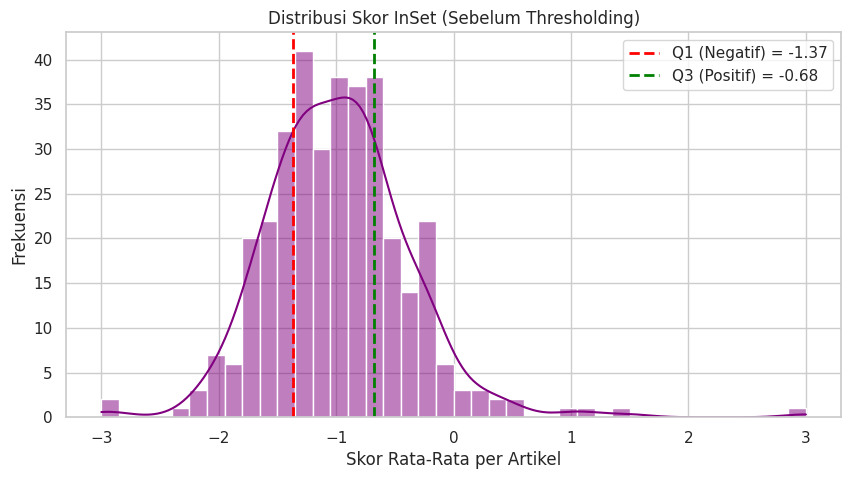

In [11]:

# 2. Terapkan Fungsi dan Hitung Skor Mentah (Mean Score)
print("🚀 Menghitung skor sentimen (dilengkapi deteksi negasi)...")
df['InSet_Score'] = df['Isi Berita Clean'].apply(calculate_inset_score_with_negation)

# 3. Hitung Kuartil untuk Statistical Thresholding
q1 = df['InSet_Score'].quantile(0.25)
q3 = df['InSet_Score'].quantile(0.75)

# 4. Visualisasi Distribusi Skor Murni
plt.figure(figsize=(10, 5))
sns.histplot(df['InSet_Score'], kde=True, bins=40, color='purple')
plt.axvline(q1, color='red', linestyle='--', linewidth=2, label=f'Q1 (Negatif) = {q1:.2f}')
plt.axvline(q3, color='green', linestyle='--', linewidth=2, label=f'Q3 (Positif) = {q3:.2f}')
plt.title('Distribusi Skor InSet (Sebelum Thresholding)')
plt.xlabel('Skor Rata-Rata per Artikel')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()


In [12]:
# 5. Terapkan Label Final Berdasarkan Threshold
def apply_statistical_threshold(score):
    if score > q3:
        return 'Positif'
    elif score < q1:
        return 'Negatif'
    else:
        return 'Netral'

df['Sentiment_InSet'] = df['InSet_Score'].apply(apply_statistical_threshold)

# 6. Laporan Performa InSet
print("\n=== LAPORAN VALIDASI INSET LEXICON ===")
print(f"Akurasi terhadap Manual: {accuracy_score(df['Sentiment'], df['Sentiment_InSet']):.2f}")
print(classification_report(df['Sentiment'], df['Sentiment_InSet']))




=== LAPORAN VALIDASI INSET LEXICON ===
Akurasi terhadap Manual: 0.45
              precision    recall  f1-score   support

     Negatif       0.67      0.42      0.52       141
      Netral       0.24      0.53      0.33        80
     Positif       0.67      0.45      0.54       132

    accuracy                           0.45       353
   macro avg       0.53      0.46      0.46       353
weighted avg       0.57      0.45      0.48       353



### KESIMPULAN PERBANDINGAN F1-SCORE

In [13]:
if 'Sentiment_TextBlob' in df.columns:
    f1_blob = f1_score(df['Sentiment'], df['Sentiment_TextBlob'], average='macro', zero_division=0)
    f1_inset = f1_score(df['Sentiment'], df['Sentiment_InSet'], average='macro', zero_division=0)

    print("\n" + "="*50)
    print("🏆 RINGKASAN PERBANDINGAN METODE VALIDASI")
    print("="*50)
    print(f"{'Metode':<20} | {'F1-Macro':<10} | {'Keterangan'}")
    print("-" * 50)
    print(f"{'TextBlob (Translated)':<20} | {f1_blob:<10.4f} | Rentan bias hasil translasi mesin")
    print(f"{'InSet (+ Negation)':<20} | {f1_inset:<10.4f} | Menangkap struktur B.Indonesia murni")




🏆 RINGKASAN PERBANDINGAN METODE VALIDASI
Metode               | F1-Macro   | Keterangan
--------------------------------------------------
TextBlob (Translated) | 0.2292     | Rentan bias hasil translasi mesin
InSet (+ Negation)   | 0.4595     | Menangkap struktur B.Indonesia murni


Kesimpulan :

# Feature Extraction

### TF-IDF


⏳ [C0] Menghitung TF-IDF...
✅ Kolom 'Isi Berita Clean' berhasil dikenali sebagai 'clean_text'

🔥 Top 20 Kata Berdasarkan TF-IDF:
bank             0.062950
indonesia        0.049798
perusahaan       0.048238
sawit            0.047058
energi           0.046251
antam            0.043270
pembiayaan       0.040829
lingkungan       0.040157
masyarakat       0.037661
mandiri          0.037611
berkelanjutan    0.036469
triliun          0.034894
iklan            0.033967
tambang          0.033732
kredit           0.033564
sektor           0.033171
hijau            0.032775
bri              0.032236
karbon           0.028474
petani           0.027263
dtype: float64


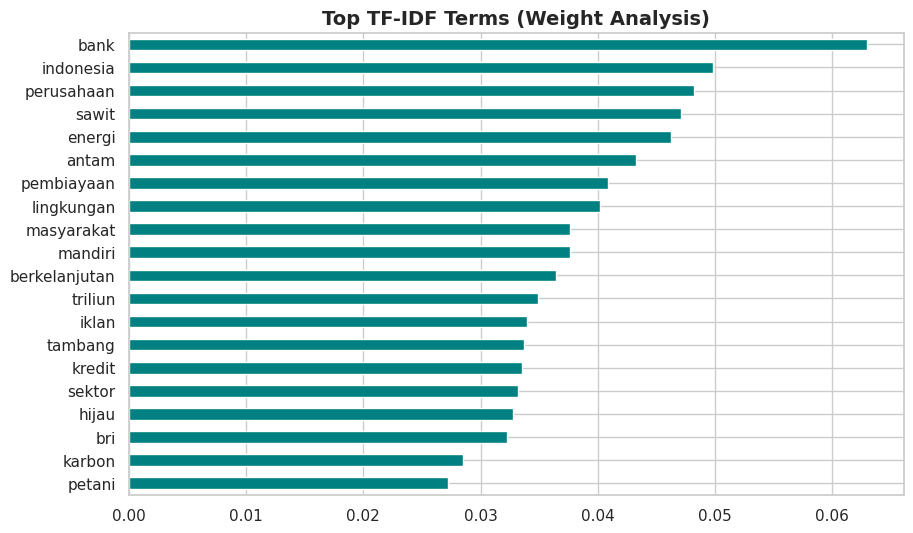

In [14]:
print('\n⏳ [C0] Menghitung TF-IDF...')

from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords sederhana (biar konsisten sama n-gram kamu)
stop_words_id = ['yang', 'dan', 'di', 'dari', 'ke', 'ini', 'itu', 'tidak', 'untuk', 'sebagai', 'kami', 'atau',
                 'dengan', 'telah', 'dalam', 'pada', 'oleh', 'juga', 'akan', 'pt', 'tbk', 'menjadi', 'tersebut', 'lebih', 'salah satu', 'salah satunya', 'tahun']


# 1. STANDARISASI KOLOM (Biar ga KeyError lagi)
if 'clean_text' not in df.columns:
    kandidat = ['Isi Berita Clean', 'Isi Berita', 'text', 'content']
    for k in kandidat:
        if k in df.columns:
            df.rename(columns={k: 'clean_text'}, inplace=True)
            print(f"✅ Kolom '{k}' berhasil dikenali sebagai 'clean_text'")
            break

# 2. EKSEKUSI TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words=stop_words_id
)
tfidf_matrix = tfidf.fit_transform(df['clean_text'].astype(str))

# Ambil fitur untuk plotting (hanya variabel lokal)
feature_names = tfidf.get_feature_names_out()
mean_tfidf = pd.Series(tfidf_matrix.toarray().mean(axis=0), index=feature_names).sort_values(ascending=False)

print('\n🔥 Top 20 Kata Berdasarkan TF-IDF:')
print(mean_tfidf.head(20))

# Plotting TF-IDF
plt.figure(figsize=(10, 6))
mean_tfidf.head(20).plot(kind='barh', color='teal')
plt.title('Top TF-IDF Terms (Weight Analysis)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

### N Gram


⏳ [C2] Ekstraksi Bigram & Trigram dengan CountVectorizer...


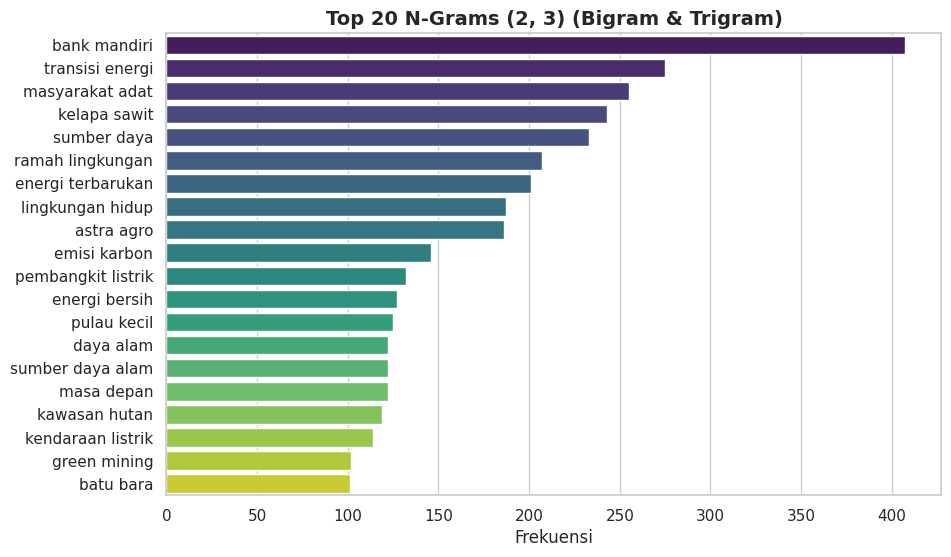

In [15]:
print('\n⏳ [C2] Ekstraksi Bigram & Trigram dengan CountVectorizer...')

def plot_top_ngrams(df, ngram_range=(2,3), top_n=20):
    """Fungsi untuk mengekstrak dan plot n-gram menggunakan scikit-learn."""

    stop_words_id = ['yang', 'dan', 'di', 'dari', 'ke', 'ini', 'itu', 'untuk',
                     'dengan', 'dalam', 'pada', 'oleh', 'juga', 'akan', 'pt', 'tbk']

    blacklist_ngrams = {
        "salah satu", "jangka panjang", "2022 lalu", "salah satunya",
        "tata kelola", "kerja sama", "direktur utama", "tidak hanya", "sebagai bagian", "tidak ada", "bagi masyarakat"
    }

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words_id)

    # Ambil teks, pastikan dalam bentuk string
    corpus = df['clean_text'].astype(str).tolist()

    try:
        X = vectorizer.fit_transform(corpus)
        # Hitung frekuensi tiap n-gram
        sum_words = X.sum(axis=0)

        # Ambil semua n-gram dan frekuensinya
        all_words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

        # FILTER: Buang n-gram yang ada di daftar blacklist
        words_freq_filtered = [wf for wf in all_words_freq if wf[0] not in blacklist_ngrams]

        # Urutkan dari yang frekuensinya paling besar, lalu potong sebanyak top_n (Top 20)
        words_freq = sorted(words_freq_filtered, key=lambda x: x[1], reverse=True)[:top_n]

        # Plotting
        if not words_freq:
            print("Tidak ada n-gram yang tersisa setelah di-filter.")
            return

        words, freqs = zip(*words_freq)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(freqs), y=list(words), palette="viridis")
        plt.title(f'Top {top_n} N-Grams {ngram_range} (Bigram & Trigram)', fontsize=14, fontweight='bold')
        plt.xlabel('Frekuensi')
        plt.show()

    except ValueError:
        print("Dataset terlalu kecil atau tidak ada kombinasi kata yang memenuhi syarat.")

# Panggil fungsinya untuk melihat visualisasinya (langsung top 20)
plot_top_ngrams(df, ngram_range=(2,3), top_n=20)

# Analisis Linguistik

In [16]:
!pip install -q transformers torch

from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict

# Load IndoBERT POS Tagger (model khusus Bahasa Indonesia)
print("⏳ Loading IndoBERT POS Tagger...")
MODEL_NAME = "w11wo/indonesian-roberta-base-posp-tagger"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
pos_pipe  = pipeline("token-classification", model=model, tokenizer=tokenizer,
                     aggregation_strategy="simple")

print("✅ Model berhasil dimuat!")

⏳ Loading IndoBERT POS Tagger...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model berhasil dimuat!


In [17]:
def pos_tag_indobert(text, max_len=128):
    """
    Jalankan POS tagging IndoBERT.
    Potong teks agar tidak melebihi batas token model.
    """
    text = str(text)
    words = text.split()[:max_len]
    short_text = " ".join(words)
    try:
        result = pos_pipe(short_text)
        return [(r['word'], r['entity_group']) for r in result]
    except Exception as e:
        return []

print("⏳ Memproses POS Tagging seluruh dataset dengan IndoBERT...")
print("(Estimasi: ~5-15 menit tergantung GPU Colab)\n")

# Aktifkan GPU jika tersedia
import torch
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU ✅' if device == 0 else 'CPU (lebih lambat)'}")

pos_pipe_fast = pipeline("token-classification", model=model, tokenizer=tokenizer,
                          aggregation_strategy="simple", device=device)

df['pos_indobert'] = df['clean_text'].apply(pos_tag_indobert)

print(f"\n✅ Selesai! {len(df)} artikel diproses.")
print("Contoh hasil baris pertama (20 token):")
print(df['pos_indobert'].iloc[0][:20])

⏳ Memproses POS Tagging seluruh dataset dengan IndoBERT...
(Estimasi: ~5-15 menit tergantung GPU Colab)

Device: CPU (lebih lambat)

✅ Selesai! 353 artikel diproses.
Contoh hasil baris pertama (20 token):
[(' Bisnis', 'NNP'), ('.', 'NNP'), ('com', 'NNP'), (',', 'SYM'), (' JAKARTA', 'NNP'), (' -', 'SYM'), (' Sukses', 'NNO'), (' dalam', 'PPO'), (' transisi', 'NNO'), (' energi', 'NNO'), (' menjadi', 'VBL'), (' salah', 'KUA'), (' tujuan', 'NNO'), (' dari', 'PPO'), (' isu', 'NNO'), (' s', 'NNO'), ('ustainable', 'NNO'), (' fin', 'NNP'), ('ancing', 'NNP'), (' yang', 'PRR')]


Label POS yang tersedia di data: ['Noun', 'Verb', 'Adjective', 'Adverb', 'Proper Noun', 'Negation', 'Conjunction']


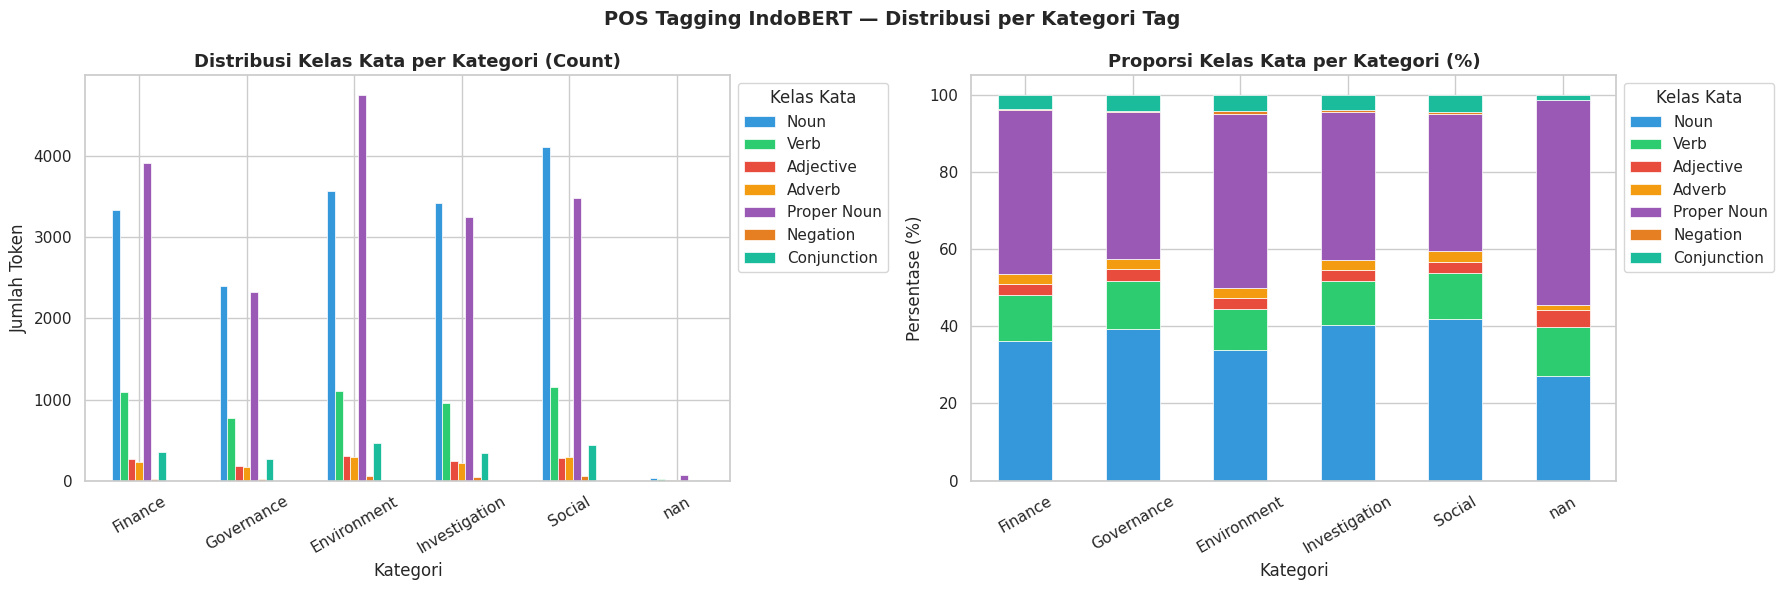


Semua label POS unik dari model:
[('NNP', 17801), ('NNO', 16887), ('SYM', 5559), ('PPO', 4282), ('NUM', 3293), ('VBT', 2559), ('CCN', 1371), ('ADJ', 1283), ('VBI', 1234), ('PRR', 895), ('VBP', 858), ('ART', 804), ('ADV', 768), ('CSN', 487), ('ADK', 426), ('VBL', 379), ('PRN', 342), ('KUA', 294), ('NEG', 198), ('UNS', 132), ('VBE', 77), ('$$$', 54), ('PAR', 53), ('PRI', 37), ('PRK', 12)]


In [18]:
# ── Distribusi POS per Kategori Tag ──
# ✅ POS_LABEL_MAP lengkap sesuai tagset model w11wo
POS_LABEL_MAP = {
    # NOUN
    'NNP': 'Proper Noun',   # Nama diri (Bank BRI, Jakarta)
    'NNO': 'Noun',          # Kata benda umum
    'NND': 'Noun',          # Kata benda turunan

    # VERB
    'VBT': 'Verb',          # Kata kerja transitif
    'VBI': 'Verb',          # Kata kerja intransitif
    'VBP': 'Verb',          # Kata kerja pasif
    'VBL': 'Verb',          # Kata kerja kopula (adalah, merupakan)
    'VBE': 'Verb',          # Kata kerja eksistensial

    # ADJECTIVE & ADVERB
    'ADJ': 'Adjective',     # Kata sifat
    'ADV': 'Adverb',        # Kata keterangan
    'ADK': 'Adverb',        # Kata keterangan (tipe lain)

    # PRONOUN
    'PPO': 'Pronoun',       # Kata ganti objek
    'PRR': 'Pronoun',       # Kata ganti relatif
    'PRN': 'Pronoun',       # Kata ganti
    'PRI': 'Pronoun',       # Kata ganti indefinit
    'PRK': 'Pronoun',       # Kata ganti interogatif

    # FUNCTION WORDS
    'CCN': 'Conjunction',   # Konjungsi
    'CSN': 'Conjunction',   # Konjungsi subordinat
    'ART': 'Particle',      # Artikel/Partikel
    'PAR': 'Particle',      # Partikel
    'KUA': 'Quantifier',    # Kata bilangan/kuantifier

    # OTHERS
    'NUM': 'Number',        # Angka
    'NEG': 'Negation',      # Negasi (tidak, bukan, belum)
    'SYM': 'Symbol',        # Simbol, tanda baca
    'UNS': 'Other',         # Tidak terklasifikasi
    '$$$': 'Other',         # Token khusus
}

MAIN_POS = ['Noun', 'Verb', 'Adjective', 'Adverb', 'Proper Noun', 'Negation', 'Conjunction']

POS_COLORS = {
    'Noun':        '#3498db',
    'Verb':        '#2ecc71',
    'Adjective':   '#e74c3c',
    'Adverb':      '#f39c12',
    'Proper Noun': '#9b59b6',
    'Negation':    '#e67e22',
    'Conjunction': '#1abc9c',
}

def map_pos(tag):
    return POS_LABEL_MAP.get(tag, 'Other')

# ✅ Cek dulu label apa saja yang benar-benar muncul di data
all_mapped = [
    map_pos(pos)
    for row in df['pos_indobert']
    for _, pos in row
]
available_pos = [p for p in MAIN_POS if p in set(all_mapped)]
print(f"Label POS yang tersedia di data: {available_pos}")

# Hitung distribusi per Tag
pos_by_tag = defaultdict(Counter)
for _, row in df.iterrows():
    tag = str(row['Tag'])
    for _, pos in row['pos_indobert']:
        mapped = map_pos(pos)
        if mapped in available_pos:  # ✅ hanya hitung yang ada
            pos_by_tag[tag][mapped] += 1

pos_df = pd.DataFrame(pos_by_tag).T.fillna(0).astype(int)

# ✅ Filter kolom hanya yang benar-benar ada
pos_df  = pos_df[[c for c in available_pos if c in pos_df.columns]]
pos_pct = pos_df.div(pos_df.sum(axis=1), axis=0) * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_used = [POS_COLORS[p] for p in pos_df.columns]

pos_df.plot(kind='bar', ax=axes[0],
            color=colors_used,
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Kelas Kata per Kategori (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Token')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Kelas Kata', bbox_to_anchor=(1, 1))

pos_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=colors_used,
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Proporsi Kelas Kata per Kategori (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Kelas Kata', bbox_to_anchor=(1, 1))

plt.suptitle('POS Tagging IndoBERT — Distribusi per Kategori Tag', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pos_distribusi_indobert.png', bbox_inches='tight')
plt.show()

# ✅ Tampilkan label asli dari model supaya bisa disesuaikan
print("\nSemua label POS unik dari model:")
raw_labels = Counter(pos for row in df['pos_indobert'] for _, pos in row)
print(raw_labels.most_common())

In [19]:
# Cek proporsi tiap kelas kata dari seluruh dataset
all_pos_mapped = [map_pos(pos) for row in df['pos_indobert'] for _, pos in row]
total = len(all_pos_mapped)
pos_dist = Counter(all_pos_mapped)

print(f"Total token: {total:,}")
print(f"\nDistribusi kelas kata:")
for label, count in pos_dist.most_common():
    pct = count / total * 100
    print(f"  {label:<15} {count:>6,}  ({pct:.1f}%)")

Total token: 60,085

Distribusi kelas kata:
  Proper Noun     17,801  (29.6%)
  Noun            16,887  (28.1%)
  Pronoun          5,568  (9.3%)
  Symbol           5,559  (9.3%)
  Verb             5,107  (8.5%)
  Number           3,293  (5.5%)
  Conjunction      1,858  (3.1%)
  Adjective        1,283  (2.1%)
  Adverb           1,194  (2.0%)
  Particle           857  (1.4%)
  Quantifier         294  (0.5%)
  Negation           198  (0.3%)
  Other              186  (0.3%)


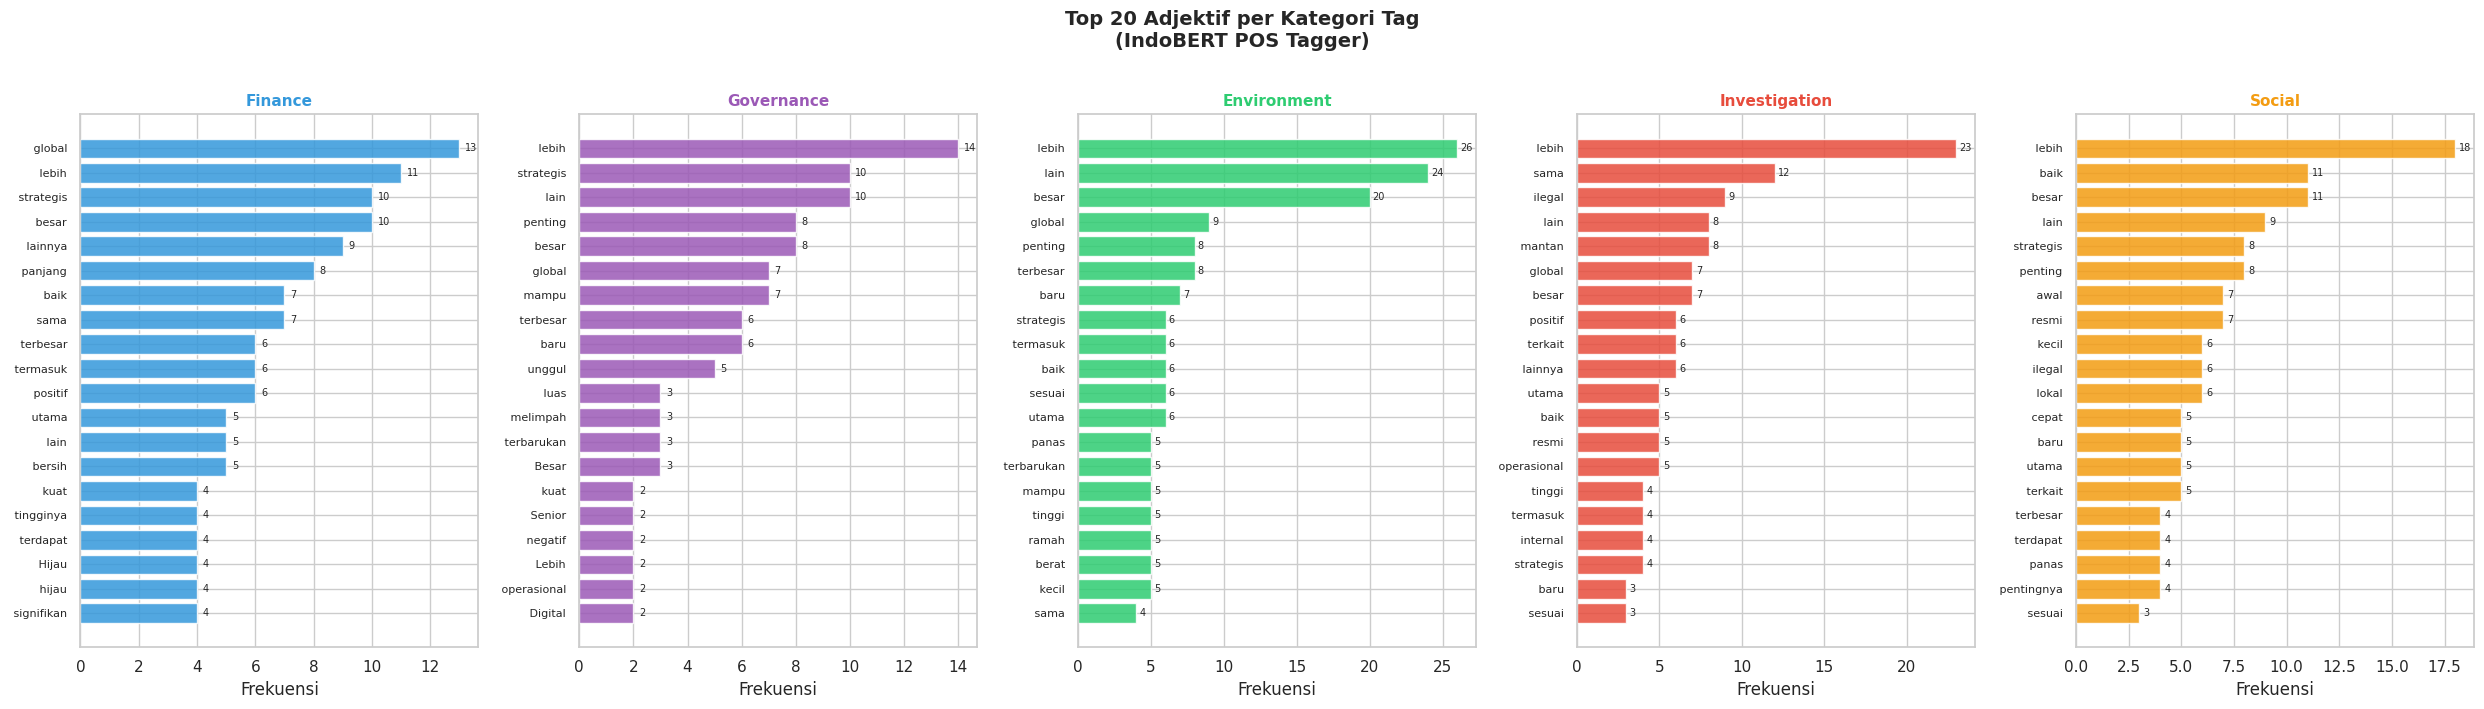

In [20]:
# ── 5A: Top Adjektif per Kategori ──
def top_adj_by_tag(df, tag, top_n=20):
    subset = df[df['Tag'] == tag]
    adjs = [
        word for row in subset['pos_indobert']
        for word, pos in row
        if map_pos(pos) == 'Adjective' and len(word) > 2
    ]
    return Counter(adjs).most_common(top_n)

TAGS = df['Tag'].dropna().unique()
TAG_COLORS_MAP = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

fig, axes = plt.subplots(1, len(TAGS), figsize=(5 * len(TAGS), 7))
fig.suptitle('Top 20 Adjektif per Kategori Tag\n(IndoBERT POS Tagger)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, tag in zip(axes, TAGS):
    top = top_adj_by_tag(df, tag, 20)
    if not top:
        ax.set_visible(False)
        continue
    words, counts = zip(*top)
    color = TAG_COLORS_MAP.get(tag, '#95a5a6')
    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(tag, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=8)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=7)

plt.tight_layout()
plt.savefig('adjektif_per_tag_indobert.png', bbox_inches='tight')
plt.show()

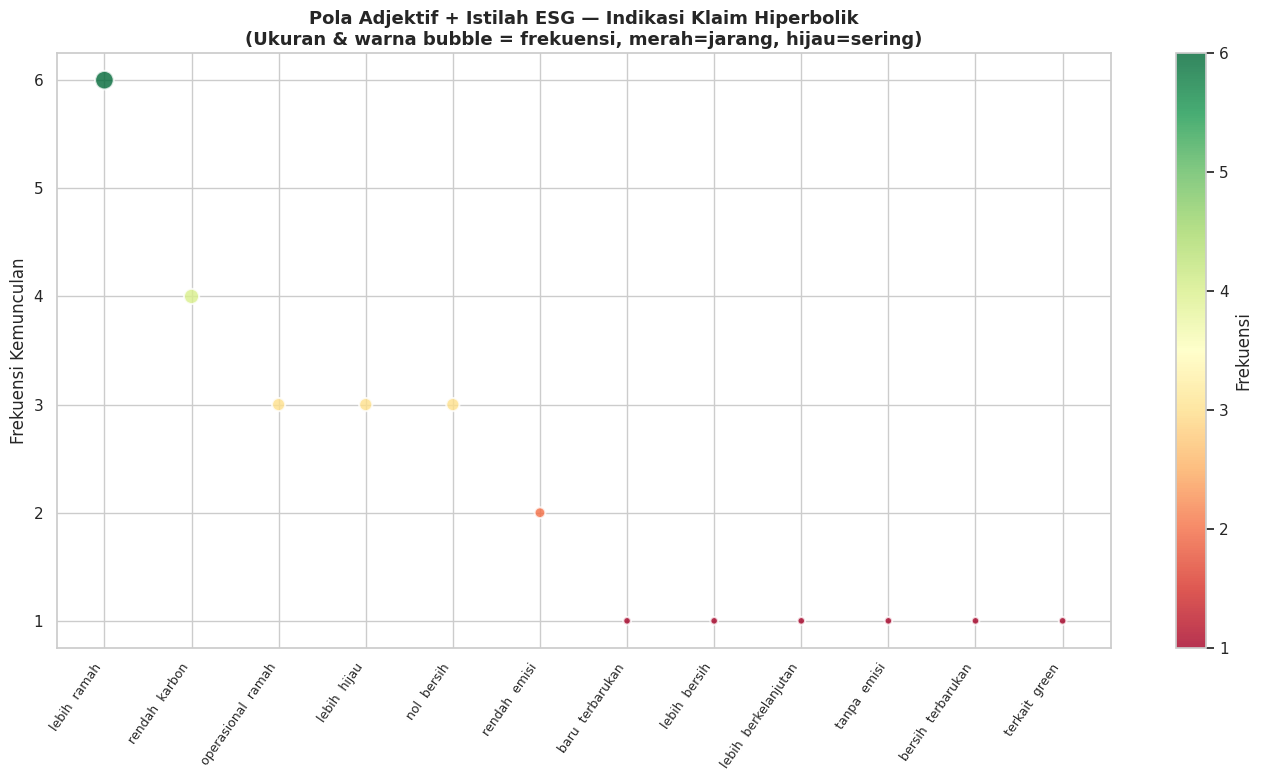

✅ Ditemukan 27 total pola, 12 pola unik


In [21]:
# ── 5B: Pola [Adjektif → Kata ESG] dari hasil IndoBERT ──
MODIFIERS = ['sangat','benar-benar','sepenuhnya','paling','makin',
             'mutlak','betul-betul','total','seluruh','penuh']
ESG_TERMS  = ['hijau','berkelanjutan','ramah','sustainability',
              'terbarukan','bersih','green','emisi','nol','karbon']

def cari_pola_adj_esg(pos_list):
    """Cari pasangan Adjektif/Adverb yang berdampingan dengan kata ESG."""
    hasil = []
    for i, (word, pos) in enumerate(pos_list):
        w = word.lower()
        if w in MODIFIERS or map_pos(pos) in ('Adjective', 'Adverb'):
            # Cek token berikutnya apakah ESG term
            if i + 1 < len(pos_list):
                next_word = pos_list[i+1][0].lower()
                if any(esg in next_word for esg in ESG_TERMS):
                    hasil.append(f"{word} {pos_list[i+1][0]}")
    return hasil

df['Pola_Adj_ESG'] = df['pos_indobert'].apply(cari_pola_adj_esg)

# Agregat semua pola
all_patterns = [p for patterns in df['Pola_Adj_ESG'] for p in patterns]
pattern_freq = Counter(all_patterns).most_common(30)

if pattern_freq:
    patterns, counts = zip(*pattern_freq)

    # Plot bubble chart
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = plt.cm.RdYlGn([c / max(counts) for c in counts])
    scatter = ax.scatter(
        range(len(patterns)), counts,
        s=[c * 30 for c in counts],
        c=counts, cmap='RdYlGn', alpha=0.8, edgecolors='white', linewidth=1.5
    )
    ax.set_xticks(range(len(patterns)))
    ax.set_xticklabels(patterns, rotation=55, ha='right', fontsize=9)
    ax.set_ylabel('Frekuensi Kemunculan')
    ax.set_title('Pola Adjektif + Istilah ESG — Indikasi Klaim Hiperbolik\n'
                 '(Ukuran & warna bubble = frekuensi, merah=jarang, hijau=sering)',
                 fontsize=13, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Frekuensi')
    plt.tight_layout()
    plt.savefig('pola_adj_esg_bubble.png', bbox_inches='tight')
    plt.show()
    print(f"✅ Ditemukan {len(all_patterns)} total pola, {len(pattern_freq)} pola unik")
else:
    print("⚠️ Tidak ada pola Adjektif+ESG yang ditemukan. Coba turunkan threshold di ESG_TERMS.")

🚨 Ditemukan 16 artikel dengan klaim ESG hiperbolik!


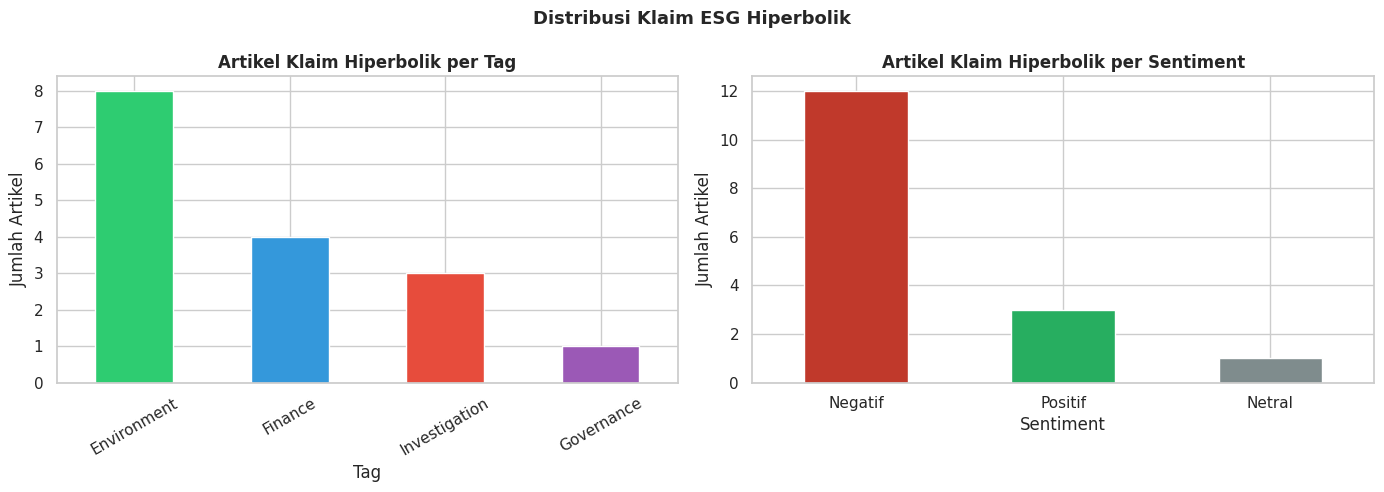

,Tag,Sentiment,Klaim_Hiperbolik
52,Finance,Positif,total green
60,Investigation,Negatif,total emisi
61,Investigation,Negatif,makin hijau
72,Investigation,Negatif,"total emisi, total emisi"
145,Environment,Netral,benar-benar ramah
161,Environment,Negatif,seluruh karbon
162,Environment,Negatif,benar-benar berkelanjutan
166,Environment,Positif,"paling hijau, total emisi"
173,Environment,Positif,total emisi
175,Environment,Negatif,total emisi


In [22]:
# Tetap berguna sebagai cross-validation dengan IndoBERT
def ekstrak_klaim_hiperbolik(text):
    text = str(text).lower()
    klaim = []
    for mod in MODIFIERS:
        for esg in ESG_TERMS:
            matches = re.findall(rf"\b{re.escape(mod)}\s+{re.escape(esg)}\b", text)
            klaim.extend(matches)
    return ", ".join(klaim) if klaim else "Tidak ada"

df['Klaim_Hiperbolik'] = df['clean_text'].apply(ekstrak_klaim_hiperbolik)
df_hiperbolik = df[df['Klaim_Hiperbolik'] != "Tidak ada"]

print(f"🚨 Ditemukan {len(df_hiperbolik)} artikel dengan klaim ESG hiperbolik!")

# Visualisasi distribusi per Tag
if len(df_hiperbolik) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Kiri: count per Tag
    df_hiperbolik['Tag'].value_counts().plot(
        kind='bar', ax=axes[0],
        color=[TAG_COLORS_MAP.get(t, '#95a5a6') for t in df_hiperbolik['Tag'].value_counts().index],
        edgecolor='white'
    )
    axes[0].set_title('Artikel Klaim Hiperbolik per Tag', fontweight='bold')
    axes[0].set_xlabel('Tag')
    axes[0].set_ylabel('Jumlah Artikel')
    axes[0].tick_params(axis='x', rotation=30)

    # Kanan: count per Sentiment
    df_hiperbolik['Sentiment'].value_counts().plot(
        kind='bar', ax=axes[1],
        color=['#c0392b','#27ae60','#7f8c8d'],
        edgecolor='white'
    )
    axes[1].set_title('Artikel Klaim Hiperbolik per Sentiment', fontweight='bold')
    axes[1].set_xlabel('Sentiment')
    axes[1].set_ylabel('Jumlah Artikel')
    axes[1].tick_params(axis='x', rotation=0)

    plt.suptitle('Distribusi Klaim ESG Hiperbolik', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('klaim_hiperbolik_distribusi.png', bbox_inches='tight')
    plt.show()

    display(df_hiperbolik[['Tag', 'Sentiment', 'Klaim_Hiperbolik']].head(10))

In [23]:
# Kata ESG target
ESG_TERMS_DEP = {
    'hijau','berkelanjutan','ramah','sustainability','terbarukan',
    'bersih','green','emisi','karbon','lingkungan','esg','iklim',
    'nol','net','zero','komitmen','target','portofolio'
}

def ekstrak_relasi_cepat(pos_list):
    """
    Ekstrak pola (Subjek -> Verb -> ESG) menggunakan logika urutan POS Tagging IndoBERT.
    pos_list format: [('kata1', 'Noun'), ('kata2', 'Verb'), ...]
    """
    if not isinstance(pos_list, list):
        return []

    pola = []

    # Iterasi setiap kata dan POS-nya
    for i, (word, pos) in enumerate(pos_list):
        word_lower = word.lower()

        # 1. Cek apakah ini kata ESG target
        if any(esg in word_lower for esg in ESG_TERMS_DEP):

            # 2. Mundur cari Verb (Maksimal mundur 5 kata biar relevan)
            verb_idx = -1
            for j in range(i-1, max(-1, i-6), -1):
                # Sesuaikan dengan label POS IndoBERT kamu (misal: 'VBT', 'VBI', atau 'Verb' jika sudah di-map)
                if pos_list[j][1] in ['VBT', 'VBI', 'VBP', 'Verb']:
                    verb_idx = j
                    break

            # 3. Kalau Verb ketemu, mundur lagi cari Subjek (Noun / Proper Noun)
            if verb_idx != -1:
                subj_word = None
                for k in range(verb_idx-1, max(-1, verb_idx-5), -1):
                    # Sesuaikan dengan label POS IndoBERT kamu (misal: 'NNP', 'NNO' atau 'Noun')
                    if pos_list[k][1] in ['NNP', 'NNO', 'Noun', 'Proper Noun']:
                        subj_word = pos_list[k][0]
                        break

                # 4. Kalau Subjek ketemu, simpan polanya!
                if subj_word:
                    pola.append({
                        'subjek': subj_word,
                        'verb': pos_list[verb_idx][0],
                        'objek_esg': word
                    })
    return pola

print("⏳ Mengekstrak pola relasi pakai logika POS IndoBERT...")
# Terapkan fungsi ke dataframe yang sudah ada POS IndoBERT-nya
df['dep_patterns'] = df['pos_indobert'].apply(ekstrak_relasi_cepat)

total = sum(len(p) for p in df['dep_patterns'])
print(f"✅ Selesai instan! Total pola ditemukan: {total}")

⏳ Mengekstrak pola relasi pakai logika POS IndoBERT...
✅ Selesai instan! Total pola ditemukan: 628


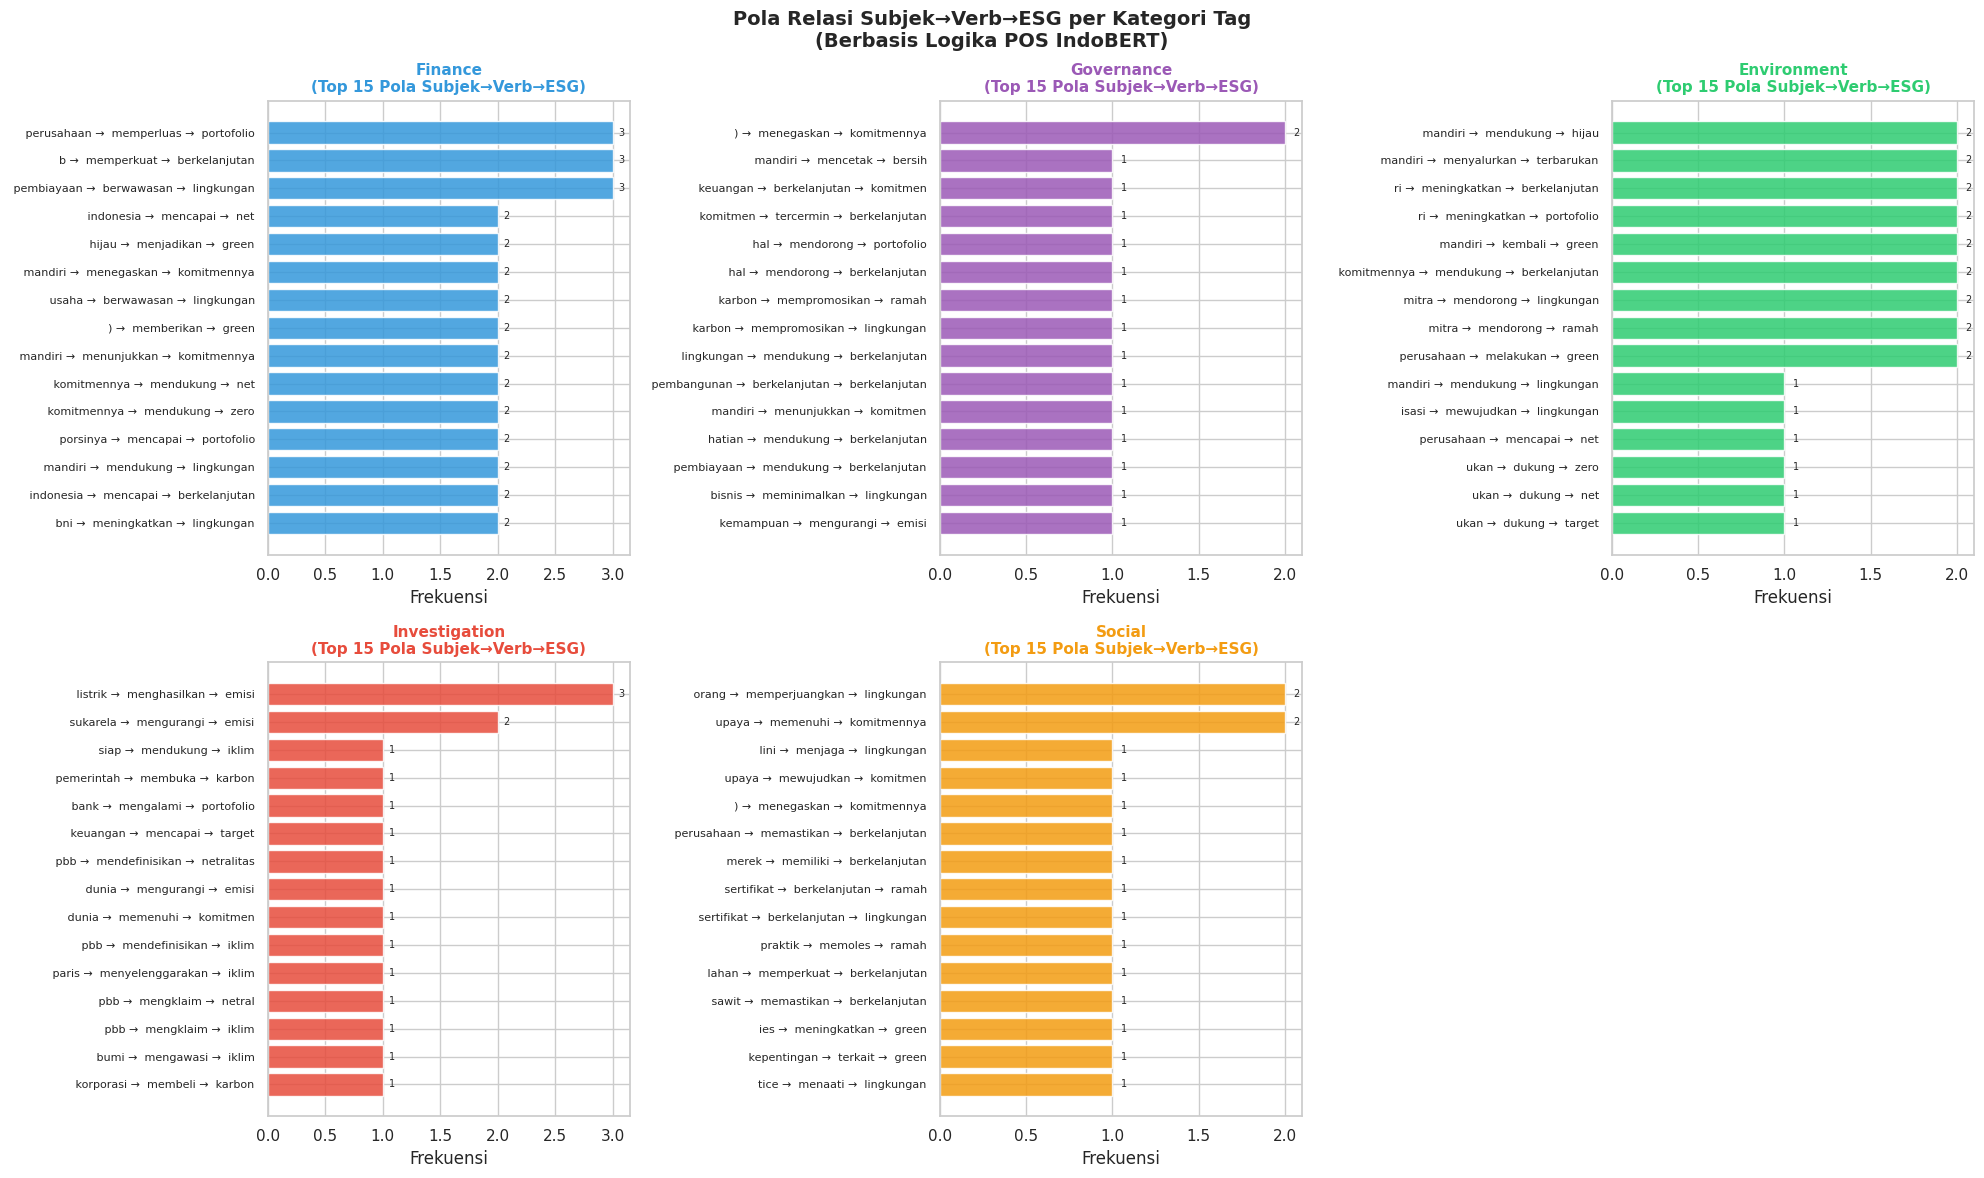

✅ Visualisasi tersimpan: dependency_per_tag.png


In [24]:
# ==============================================================================
# VISUALISASI POLA RELASI (SUBJEK -> VERB -> ESG) PER KATEGORI TAG
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd

TAG_COLORS_MAP = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

# Ambil tag unik yang ada di dataset
TAGS = df['Tag'].dropna().unique()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, tag in enumerate(TAGS):
    subset  = df[df['Tag'] == tag]

    # Ekstrak pola dari subset, pastikan formatnya list
    pola_tag = [p for patterns in subset['dep_patterns'] if isinstance(patterns, list) for p in patterns]

    # Kalau tidak ada pola yang ditemukan di tag ini
    if not pola_tag:
        axes[i].text(0.5, 0.5, f'Tidak ada pola\ndi kategori {tag}',
                     ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(tag, fontweight='bold', color=TAG_COLORS_MAP.get(tag,'gray'))
        axes[i].axis('off')
        continue

    # Kalau ada polanya, bikin DataFrame dan hitung frekuensinya
    dep_tag   = pd.DataFrame(pola_tag)
    top_triple_tag = (dep_tag['subjek'].str.lower() + ' → ' +
                      dep_tag['verb'].str.lower()   + ' → ' +
                      dep_tag['objek_esg'].str.lower()).value_counts().head(15)

    color = TAG_COLORS_MAP.get(tag, '#95a5a6')
    bars  = axes[i].barh(top_triple_tag.index[::-1], top_triple_tag.values[::-1],
                          color=color, alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{tag}\n(Top 15 Pola Subjek→Verb→ESG)',
                       fontsize=11, fontweight='bold', color=color)
    axes[i].set_xlabel('Frekuensi')
    axes[i].tick_params(axis='y', labelsize=8)

    # Tambahkan angka frekuensi di ujung tiap bar
    for bar, val in zip(bars, top_triple_tag.values[::-1]):
        axes[i].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                     str(val), va='center', fontsize=7)

# Sembunyikan subplot kosong (jika jumlah tag ganjil/kurang dari 6)
for j in range(len(TAGS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Pola Relasi Subjek→Verb→ESG per Kategori Tag\n(Berbasis Logika POS IndoBERT)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dependency_per_tag.png', bbox_inches='tight')
plt.show()

print("✅ Visualisasi tersimpan: dependency_per_tag.png")

### NER using IndoBERT

In [26]:
# @title
print('\n⏳ [C3] Menjalankan IndoBERT untuk ekstraksi ORG & LOC (Proses ini butuh waktu)...')

# Load pipeline IndoBERT NER dari HuggingFace
# aggregation_strategy="simple" otomatis menggabungkan B-ORG dan I-ORG menjadi satu kata utuh
ner_pipeline = pipeline(
    "ner",
    model="cahya/bert-base-indonesian-NER",
    aggregation_strategy="simple",
    device=-1 # Gunakan 0 jika Colab kamu pakai GPU, -1 untuk CPU
)

def ekstrak_indobert_ner(teks):
    # Batasi teks maksimal ~500 karakter agar BERT tidak error (out of sequence length)
    teks_potong = str(teks)[:500]
    hasil_ner = ner_pipeline(teks_potong)

    orgs = set()
    locs = set()

    for ent in hasil_ner:
        if ent['entity_group'] == 'ORG':
            orgs.add(ent['word'])
        elif ent['entity_group'] == 'LOC':
            locs.add(ent['word'])

    return ", ".join(list(orgs)), ", ".join(list(locs))

    # Aplikasikan ke dataframe
df[['IndoBERT_ORG', 'IndoBERT_LOC']] = df.apply(lambda row: pd.Series(ekstrak_indobert_ner(row['clean_text'])), axis=1)

print('✅ Ekstraksi IndoBERT NER Selesai!')
display(df[['IndoBERT_ORG', 'IndoBERT_LOC', 'clean_text']].head(5))


⏳ [C3] Menjalankan IndoBERT untuk ekstraksi ORG & LOC (Proses ini butuh waktu)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Ekstraksi IndoBERT NER Selesai!


,IndoBERT_ORG,IndoBERT_LOC,clean_text
0,"pt bank rakyat indonesia, bisnis. com",,"Bisnis.com, JAKARTA - Sukses dalam transisi en..."
1,"bank mandiri, bm, bisnis. com",,"Bisnis.com, JAKARTA - Bank Mandiri berhasil me..."
2,"bank mandiri, bisnis. com, direktur utama bank...",,"Bisnis.com, JAKARTA - Bank Mandiri terus mempe..."
3,"bank mandiri, idxcarbon, bisnis. com",,"Bisnis.com, JAKARTA - Bank Mandiri kembali men..."
4,"kontan. co. id, bsi, direktur utama bsi, pt ba...",,Reporter Selvi Mayasari Editor Ignatia Maria S...


In [27]:
def ekstrak_indobert_ner(teks):
    teks_potong = str(teks)[:500]
    hasil_ner = ner_pipeline(teks_potong)
    orgs = set()
    locs = set()
    for ent in hasil_ner:
        if ent['entity_group'] == 'ORG':
            orgs.add(ent['word'])
        elif ent['entity_group'] == 'LOC':
            locs.add(ent['word'])
    return ", ".join(list(orgs)), ", ".join(list(locs))

# ✅ Ini harus di LUAR fungsi (indentasi rata kiri)
df[['IndoBERT_ORG', 'IndoBERT_LOC']] = df.apply(
    lambda row: pd.Series(ekstrak_indobert_ner(row['clean_text'])), axis=1
)

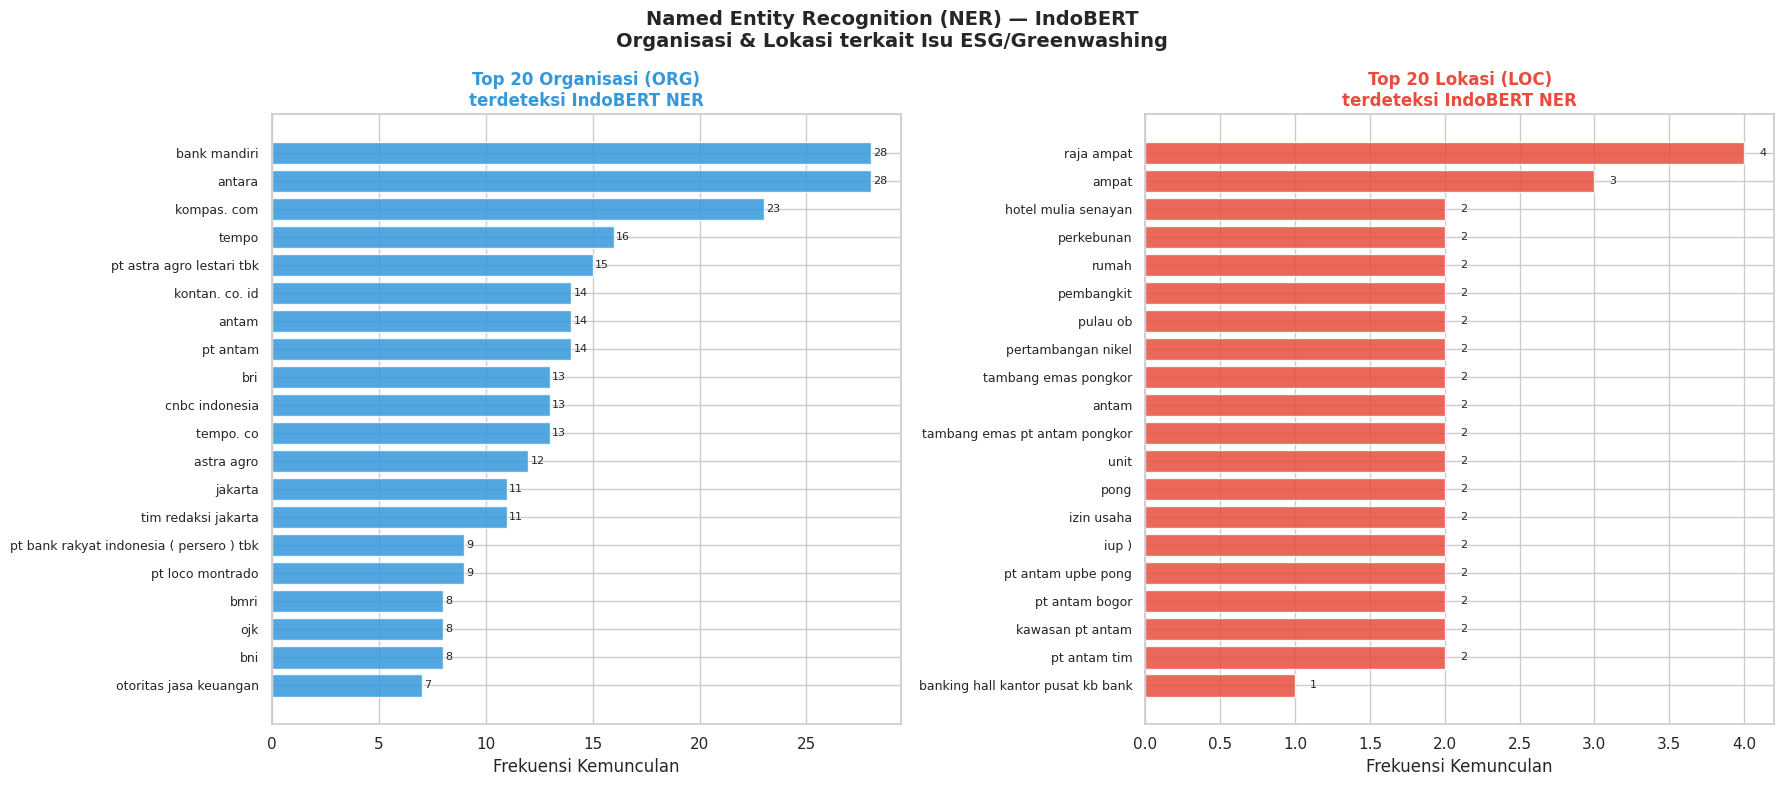

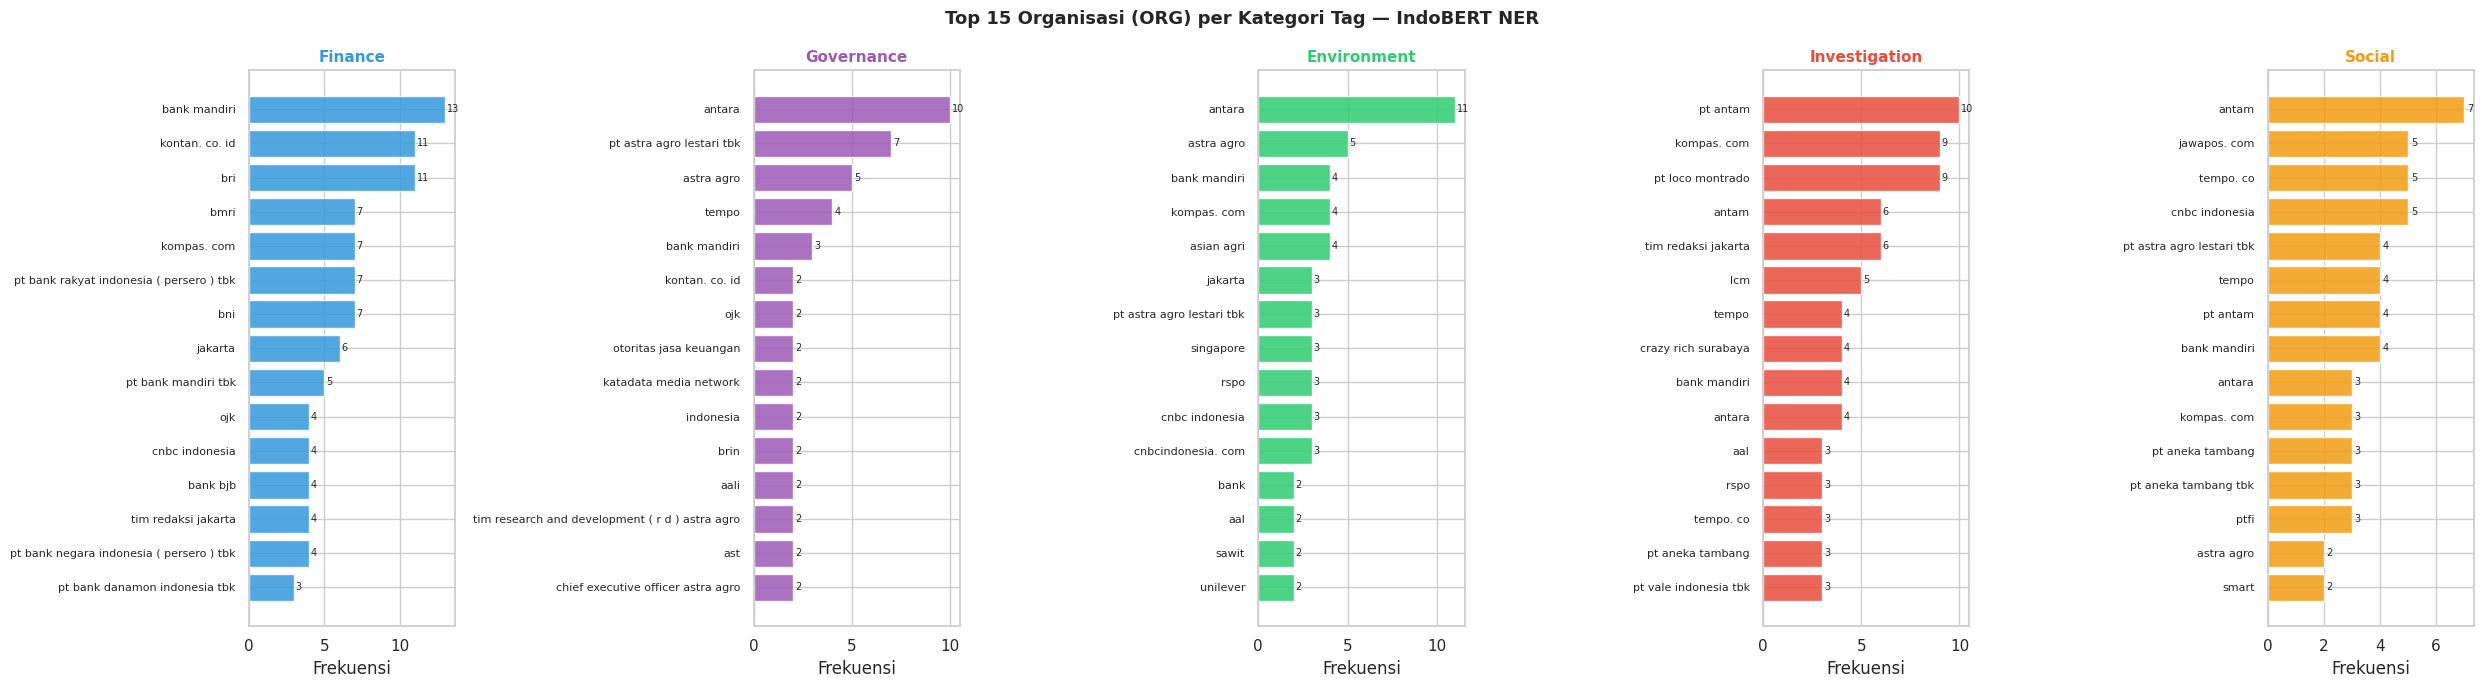

✅ Visualisasi NER tersimpan!


In [28]:
# ── Visualisasi Top ORG & LOC ──
from collections import Counter

# Pecah string kembali jadi list, buang yang kosong
all_orgs = [o.strip() for orgs in df['IndoBERT_ORG'] for o in orgs.split(',') if o.strip()]
all_locs = [l.strip() for locs in df['IndoBERT_LOC'] for l in locs.split(',') if l.strip()]

top_orgs = Counter(all_orgs).most_common(20)
top_locs = Counter(all_locs).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot ORG
if top_orgs:
    words, counts = zip(*top_orgs)
    bars = axes[0].barh(list(words)[::-1], list(counts)[::-1],
                        color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].set_title('Top 20 Organisasi (ORG)\nterdeteksi IndoBERT NER',
                      fontsize=12, fontweight='bold', color='#3498db')
    axes[0].set_xlabel('Frekuensi Kemunculan')
    axes[0].tick_params(axis='y', labelsize=9)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=8)

# Plot LOC
if top_locs:
    words, counts = zip(*top_locs)
    bars2 = axes[1].barh(list(words)[::-1], list(counts)[::-1],
                         color='#e74c3c', alpha=0.85, edgecolor='white')
    axes[1].set_title('Top 20 Lokasi (LOC)\nterdeteksi IndoBERT NER',
                      fontsize=12, fontweight='bold', color='#e74c3c')
    axes[1].set_xlabel('Frekuensi Kemunculan')
    axes[1].tick_params(axis='y', labelsize=9)
    for bar, cnt in zip(bars2, list(counts)[::-1]):
        axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=8)

plt.suptitle('Named Entity Recognition (NER) — IndoBERT\nOrganisasi & Lokasi terkait Isu ESG/Greenwashing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_org_loc_indobert.png', bbox_inches='tight')
plt.show()

# ── Bonus: ORG per Kategori Tag ──
fig, axes = plt.subplots(1, len(df['Tag'].dropna().unique()), figsize=(5 * len(df['Tag'].dropna().unique()), 7))

TAG_COLORS_MAP = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

for ax, tag in zip(axes, df['Tag'].dropna().unique()):
    subset_orgs = [
        o.strip()
        for orgs in df[df['Tag']==tag]['IndoBERT_ORG']
        for o in orgs.split(',') if o.strip()
    ]
    top = Counter(subset_orgs).most_common(15)
    if not top:
        ax.set_visible(False)
        continue
    words, counts = zip(*top)
    color = TAG_COLORS_MAP.get(tag, '#95a5a6')
    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(tag, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=8)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=7)

plt.suptitle('Top 15 Organisasi (ORG) per Kategori Tag — IndoBERT NER',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_org_per_tag.png', bbox_inches='tight')
plt.show()
print('✅ Visualisasi NER tersimpan!')

In [ ]:
print('\n⏳ Menyimpan hasil ke CSV...')
df.to_csv('IndoBERT.csv', index=False)
print('✅ File berhasil dibuat')